# Tuning and model selection: does complexity earn its keep?
### Real Estate Machine · Graduation Project

Notebook 08 produced a linear baseline that is honest, fully diagnosed, and **not good enough**: a typical
house is valued about 12.5% away from its sale price, and the IAAO uniformity test fails.

This notebook is not "try a fancier model and hope". It has a specific structure, and the structure is the point:

1. **Write down what you expect before you run anything.** Notebook 08 diagnosed exactly two failures.
   A tree model should fix one of them and cannot fix the other. Section 3 commits to that prediction
   in writing, and section 9 checks it.
2. **Tune with a small grid and a stated rule** — the search space is a decision you defend, not a
   number you copied.
3. **Pick the winner on the business metric, and then prove it is a winner.** A model that is 0.2
   percentage points better on 869 test houses may not be better at all. Section 8 tests that instead
   of assuming it.
4. **Re-run notebook 08's diagnostics on the new model.** A comparison table shows *that* something
   improved. Re-running the residual analysis shows *what* improved — which is the part a reviewer
   can ask about.

---

## Outputs
| Output | Why it exists |
|---|---|
| `Models/regressor.pkl` | the final model the Streamlit app loads |
| `Models/regressor_config.pkl` | the contract: features, transform, chosen metric, interval |
| `Models/model_comparison.csv` | the table that goes straight onto a slide |
| `Models/shap_values_test.npz` | SHAP contributions, reused by the LLM layer |
| six figures in `reports/figures/` | tuning curve, comparison, decile, segment, importances, SHAP |

**Run time warning.** The three grid searches fit 180 models between them. On a laptop expect
roughly three to six minutes for section 6. That is the price of a searched hyperparameter instead
of a guessed one; do not shrink the grid to make it faster, and do not walk away without noting the
time — the comparison table has a `time` column and a reviewer may ask about it.

---
## 1. Setup

Identical to notebook 08, deliberately. Same clean file, same split file, same preprocessing module. If a
single one of those changed, this notebook's numbers could not be compared with notebook 08's, and the whole
point of this notebook is the comparison.

In [ ]:
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")

DATA = Path("..") / "Data"
MODELS = Path("..") / "Models"
FIGS = Path("..") / "reports" / "figures"
MODELS.mkdir(exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

sys.path.append(str((Path("..") / "app").resolve()))
import preprocessing as P

raw = pd.read_csv(DATA / "data_clean.csv", dtype={"zipcode": str})
df = P.engineer_features(raw)

split = pd.read_csv(DATA / "split_indices.csv", index_col="row")["split"]
is_train = (split.values == "train")
is_test = ~is_train

X = df[P.ALL_FEATURES]
y = np.log1p(df["price"])

X_train, X_test = X[is_train], X[is_test]
y_train, y_test = y[is_train], y[is_test]

price_test = np.expm1(y_test).values
segment_test = pd.read_csv(DATA / "data_clustered.csv")["segment"].values[is_test]

print(f"Train {X_train.shape[0]:,} x {X_train.shape[1]}   Test {X_test.shape[0]:,} x {X_test.shape[1]}")
print("Same rows as notebooks 06, 07 and 08.")

Train 3,476 x 20   Test 869 x 20
Same rows as notebooks 06, 07 and 08.


### Optional libraries, checked once and loudly

Two packages are used below and neither ships with scikit-learn. Check them **now**, not in the
middle of a grid search, and let the notebook keep running without them rather than dying at cell 30.

- **XGBoost** — a third gradient-boosting implementation. If it is missing, the notebook compares
  scikit-learn's own `GradientBoostingRegressor` instead and says so. No result below depends on
  XGBoost winning.
- **SHAP** — needed for section 11 *and* for the LLM layer, which is built on SHAP
  contributions. If it is missing, install it before notebook 10: `pip install shap`.

In [ ]:
try:
    import xgboost as xgb
    HAS_XGB = True
    print(f"xgboost {xgb.__version__}")
except ImportError:
    HAS_XGB = False
    print("xgboost NOT installed - the notebook will run without it (pip install xgboost)")


try:
    import shap
    HAS_SHAP = True
    print(f"shap {shap.__version__}")
except ImportError:
    HAS_SHAP = False
    print("shap NOT installed - section 11 will be skipped. Notebook 10 NEEDS it: pip install shap")

xgboost 3.4.0
shap 0.52.0


---
## 2. The same scoring function, and one new column

Copied from notebook 08 without a single change. That is not laziness — a comparison table whose rows were
scored by two slightly different functions is worse than no table at all.

One column is added: **fit time**. It is a real deployment consideration. A model that takes four minutes to fit and half a second to predict is fine; the
Streamlit app only ever predicts. But a model that takes four minutes to *tune* costs you every time
you change a feature, and that is a cost you should be able to state.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def score(y_true_log, y_pred_log, label):
    # Identical to notebook 08. Do not edit one copy without editing the other.
    true_d = np.expm1(y_true_log)
    pred_d = np.expm1(y_pred_log)
    ape = np.abs(pred_d - true_d) / true_d

    return {
        "model": label,
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_$": mean_absolute_error(true_d, pred_d),
        "RMSE_$": np.sqrt(mean_squared_error(true_d, pred_d)),
        "MedAPE_%": 100 * np.median(ape),
        "MAPE_%": 100 * ape.mean(),
        "PPE10_%": 100 * (ape <= 0.10).mean(),
        "PPE20_%": 100 * (ape <= 0.20).mean(),
    }


def show(rows, extra=()):
    cols = ["R2_log", "MAE_$", "MedAPE_%", "MAPE_%", "PPE10_%", "PPE20_%", *extra]
    t = pd.DataFrame(rows).set_index("model")[cols]
    fmt = {"R2_log": "{:.4f}", "MAE_$": "${:,.0f}", "MedAPE_%": "{:.2f}%", "MAPE_%": "{:.2f}%",
           "PPE10_%": "{:.1f}%", "PPE20_%": "{:.1f}%", "train_R2": "{:.4f}", "fit_s": "{:.2f}s",
           "search_s": "{:.0f}s"}
    return t.style.format({k: v for k, v in fmt.items() if k in t.columns})


results = []
print("Scoring function defined - identical to notebook 08.")

Scoring function defined - identical to notebook 08.


### Bringing notebook 08's baseline forward

The Ridge baseline is the thing this notebook has to beat, so it must appear in this notebook's table scored by this notebook's code. Load it if notebook 08 saved it; refit it in four seconds if not.

Note the fallback refits with `alpha=100` — the value notebook 08's one-standard-error rule selected. It is
hard-coded here rather than re-searched, because re-searching it would silently let this notebook disagree with notebook 08.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
    
if (MODELS / "regression_baseline.pkl").exists():
    baseline = joblib.load(MODELS / "regression_baseline.pkl")
    print("Loaded Models/regression_baseline.pkl from notebook 08.")
else:
    baseline = Pipeline([("pre", P.build_preprocessor(smoothing=20)),
                         ("model", Ridge(alpha=100))]).fit(X_train, y_train)
    print("notebook 08 pickle not found - refitted Ridge(alpha=100), the value notebook 08 selected.")

base_pred_log = baseline.predict(X_test)
row = score(y_test, base_pred_log, "Ridge baseline")
row["fit_s"] = np.nan
row["train_R2"] = r2_score(y_train, baseline.predict(X_train))
results.append(row)

show(results, extra=["train_R2"])

Loaded Models/regression_baseline.pkl from notebook 08.


,R2_log,MAE_$,MedAPE_%,MAPE_%,PPE10_%,PPE20_%,train_R2
model,,,,,,,
Ridge baseline,0.8270,"$103,010",12.52%,16.83%,41.0%,69.6%,0.8411


---
## 3. Write the prediction down before you run anything

This is the habit that separates an experiment from a fishing trip. Notebook 08 diagnosed two specific
failures. State now what a tree-based model should and should not do about them, so that section 9 is
a test rather than a description.

**What a tree does that a straight line cannot.** A linear model says: every extra standard deviation
of `sqft_living` adds the same percentage to the price, everywhere, for every house. A tree splits
the data into boxes and fits a constant in each box, so it can learn that an extra 500 sqft is worth
a lot in one zip code and almost nothing in another. That is an **interaction**, and this dataset is
full of them — the whole business report is built on the claim that location changes what size is
worth.

**What a tree still cannot do.** A tree's prediction is an average of training rows in a leaf.
It therefore can never predict a value outside the range it was trained on, and near the edges of the
data it has fewer rows to average, so it pulls toward the middle exactly like the linear model did.

| Baseline finding | Prediction | Reason |
|---|---|---|
| MedAPE 12.5%, above the 7.5% off-market Zestimate benchmark | improves, but stays above the benchmark | the missing information is coordinates and quality grade, and no algorithm invents data |
| IAAO **COD 16.9 fails** the 5–15 uniformity band | should improve, possibly into the band | COD measures spread of individual errors, which is what interactions reduce |
| Cheapest decile over-valued ~20%, most expensive under-valued | reduced but **not removed** | trees cannot extrapolate past the training range |
| Premium View Property ~2x the error of other segments | still the worst segment | 76 test houses and no view-quality feature; this is a data problem |

If section 9 contradicts any of these, that is interesting and you report it. What you must not do is
run the models first and then write down what you expected.

---
## 4. Does a tree need the preprocessing pipeline? Two different answers

A fair question, and the answer is not the same for both halves of the preprocessor.

**`StandardScaler` — unnecessary, and kept anyway.** A tree splits on `sqft_living > 2150`. Rescale
the column and the split becomes `> 0.43`; the partition of the rows is *identical*. Scaling cannot
change a tree's predictions. It is kept because dropping it would change nothing except making the
two notebooks harder to compare, and because the pipeline object is what the app loads.

**`SmoothedTargetEncoder` — essential, and the reason the pipeline must stay.** `zipcode` is text
with 77 levels. Without the encoder there is nothing to split on. The alternatives are worse:
one-hot encoding 77 zip codes gives a tree 77 near-useless binary columns, each of which can only
separate one zip code from all others, and the tree burns its depth budget on them.

**And the leakage rule does not relax for trees.** The encoder is fitted *inside* the pipeline, so
when `GridSearchCV` refits on each of the five folds, the zip-code price map is rebuilt from four
folds and applied to the fifth. Fit the encoder once outside the search and every one of the 900 CV
scores below is contaminated.

> **In one sentence:** scaling is irrelevant to a tree and I kept it only for
> comparability; target encoding is what makes location usable by a tree at all, and it stays inside
> the pipeline so that cross-validation never encodes a fold with its own prices.

---
## 5. Defaults first — and overfitting you can see

Before any tuning, fit all three families at their default settings. This costs seconds and buys two
things: a floor for the tuning to beat, and the clearest illustration of the bias–variance trade-off
you will get in this project.

Watch the **`train_R2`** column against `R2_log` (which is the test score). The gap between them is
variance — the part of the model that has memorised the training rows rather than learned the market.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

default_models = {
    "RF (defaults)": RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "GB (defaults)": GradientBoostingRegressor(random_state=42),
}
if HAS_XGB:
    default_models["XGB (defaults)"] = xgb.XGBRegressor(
        n_estimators=400, random_state=42, n_jobs=-1, tree_method="hist")

for name, model in default_models.items():
    pipe = Pipeline([("pre", P.build_preprocessor(smoothing=20)), ("model", model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0

    r = score(y_test, pipe.predict(X_test), name)
    r["fit_s"] = elapsed
    r["train_R2"] = r2_score(y_train, pipe.predict(X_train))
    results.append(r)

show(results, extra=["train_R2", "fit_s"])

,R2_log,MAE_$,MedAPE_%,MAPE_%,PPE10_%,PPE20_%,train_R2,fit_s
model,,,,,,,,
Ridge baseline,0.8270,"$103,010",12.52%,16.83%,41.0%,69.6%,0.8411,nans
RF (defaults),0.8413,"$88,576",11.21%,15.24%,45.9%,73.8%,0.9599,2.49s
GB (defaults),0.8573,"$84,127",11.10%,15.03%,46.1%,71.7%,0.8894,1.22s
XGB (defaults),0.8413,"$91,724",11.45%,15.74%,44.0%,73.9%,0.9804,1.86s


### Read the two R-squared columns together — this is the whole of bias and variance

Every tree model beats the linear baseline on the test set straight out of the box. That alone is
worth a sentence: the improvement comes from interactions the linear model was structurally unable to
represent, not from tuning.

But look at the train column:

- **Random Forest:** trains to about 0.96, tests at about 0.84. It has grown every tree until the
  leaves are nearly pure, so it can reproduce the training set almost exactly. That gap is variance.
  A forest tolerates it because averaging 400 differently-random trees cancels most of the noise —
  that is what the "forest" is for.
- **XGBoost at defaults:** trains to about 0.98 and tests *worse* than gradient boosting does. This
  is the honest picture of an over-fitted booster: 400 rounds at a learning rate of 0.3 on 3,476 rows
  is far too much capacity. Tuning it is not cosmetic; it is a repair.
- **Gradient Boosting at defaults:** trains to about 0.89 and tests at about 0.86 — the smallest gap
  of the three, because its defaults are conservative (100 rounds, depth 3, learning rate 0.1).

> **How do we know the model is not overfitting?** I report train and test $R^2$ side by side for every model. My default XGBoost
> trains to 0.98 and tests at 0.84, which is overfitting, and it is why I tuned toward more
> regularisation: a lower learning rate, shallower trees and subsampling. My final model's gap is
> about five points, and its cross-validated score on the training set agrees with its test score,
> which is the check that matters.

**A trap to avoid:** do not "fix" a train–test gap by picking the model with the smallest gap. A
model that trains to 0.50 and tests at 0.50 has no gap and is useless. The gap is diagnostic
information, not the objective. The objective is the test-set business metric.

---
## 6. `GridSearchCV` — a small grid you can defend

The grid is capped at about 12 combinations per model family. That is not an arbitrary limit,
constraints:

1. **Time.** Each combination is fitted five times (five folds). Twelve combinations is 60 fits per
   model family, 180 fits in this section.
2. **Multiple comparisons.** Every extra combination is another chance for one to look good on the
   validation folds by luck. Search a thousand combinations on 3,476 rows and the winner is partly
   noise. A small grid over parameters chosen for a *reason* is better science than a large grid over
   everything.

### What each hyperparameter actually controls

| Model | Parameter | What it does | Why this range |
|---|---|---|---|
| RF | `max_features` | how many features each split may consider | the point of a forest is *decorrelated* trees; with `zipcode_te` dominating, letting every tree see every feature makes them all pick it first and vote identically |
| RF | `min_samples_leaf` | smallest allowed leaf | 1 memorises; 5 smooths. This is the forest's main regularisation dial |
| RF | `max_depth` | tree height | unlimited vs 20, to see whether depth is even binding |
| GB / XGB | `learning_rate` | how much of each tree's correction is kept | boosting's core trade-off: smaller steps generalise better but need more rounds |
| GB / XGB | `n_estimators` | number of boosting rounds | must rise as the learning rate falls; the two are one decision, which is why they are searched together |
| GB / XGB | `max_depth` | interaction order per tree | depth 2 learns pairwise effects, depth 6 learns six-way ones — on 3,476 rows depth 6 is usually memorising |

Scoring is `r2` on the log target, which is what the models optimise. The **business metric decides
the winner in section 8**, on the test set, after the search is finished. Selecting hyperparameters
on MedAPE would mean optimising a median through five folds of 695 rows each — noisier, slower, and
it buys nothing on this data.

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
searches = {}


def tune(label, model, grid):
    """Grid-search one model family. Returns the refitted best pipeline."""
    gs = GridSearchCV(
        Pipeline([("pre", P.build_preprocessor(smoothing=20)), ("model", model)]),
        grid, cv=kf, scoring="r2", n_jobs=-1, refit=True,
    )
    t0 = time.time()
    gs.fit(X_train, y_train)
    search_s = time.time() - t0

    n_combos = len(gs.cv_results_["params"])
    best = {k.replace("model__", ""): v for k, v in gs.best_params_.items()}
    print(f"{label}: {n_combos} combos x 5 folds = {n_combos * 5} fits in {search_s:.0f}s")
    print(f"{label}: best CV R2 = {gs.best_score_:.4f}   params = {best}\n")

    t0 = time.time()
    gs.best_estimator_.fit(X_train, y_train)
    fit_s = time.time() - t0

    r = score(y_test, gs.predict(X_test), label)
    r["fit_s"] = fit_s
    r["search_s"] = search_s
    r["cv_R2"] = gs.best_score_
    r["train_R2"] = r2_score(y_train, gs.predict(X_train))
    results.append(r)
    searches[label] = gs
    return gs


print("Starting the searches. Expect several minutes in total.\n")

Starting the searches. Expect several minutes in total.



In [ ]:
gs_rf = tune("RF (tuned)", RandomForestRegressor(random_state=42), {
    "model__n_estimators": [400],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": [0.3, 0.6],
})

RF (tuned): 12 combos x 5 folds = 60 fits in 57s
RF (tuned): best CV R2 = 0.8409   params = {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 400}



In [ ]:
gs_gb = tune("GB (tuned)", GradientBoostingRegressor(random_state=42), {
    "model__n_estimators": [300, 600],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],
})

GB (tuned): 12 combos x 5 folds = 60 fits in 43s
GB (tuned): best CV R2 = 0.8545   params = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 600}



In [ ]:
if HAS_XGB:
    gs_xgb = tune("XGB (tuned)",
                  xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist",
                                   subsample=0.8, colsample_bytree=0.8), {
        "model__n_estimators": [400, 800],
        "model__learning_rate": [0.03, 0.06],
        "model__max_depth": [3, 4, 6],
    })
else:
    print("XGBoost not installed - skipped.")

XGB (tuned): 12 combos x 5 folds = 60 fits in 23s
XGB (tuned): best CV R2 = 0.8554   params = {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 800}



### Two notes on the searches themselves

**`subsample=0.8` and `colsample_bytree=0.8` are fixed, not searched, for XGBoost.** They are outside
the grid because adding them would double or quadruple the combination count for a pair of settings
that are near-universally beneficial: each tree sees 80% of the rows and 80% of the columns, which
decorrelates the trees for the same reason `max_features` does in a forest. Fixing a parameter at a
sensible value and saying so is a legitimate choice; pretending you searched it is not.

**The RF grid holds `n_estimators` at 400 instead of searching it.** More trees in a forest never
hurt accuracy — they only cost time — so searching that parameter would spend fits on a question with
a known answer. Boosting is the opposite: more rounds *can* overfit, which is exactly why
`n_estimators` is in the GB and XGB grids and paired with the learning rate.

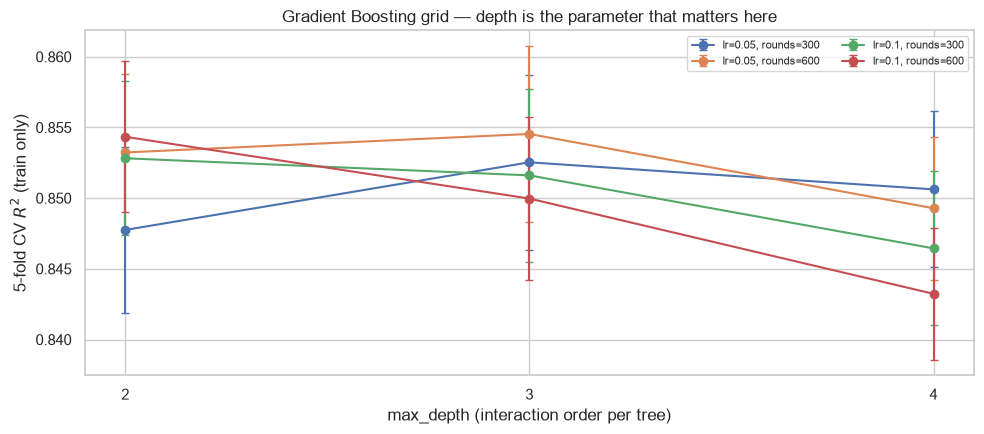

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
gb_res = pd.DataFrame(gs_gb.cv_results_)
gb_res["depth"] = gb_res["param_model__max_depth"].astype(int)
gb_res["lr"] = gb_res["param_model__learning_rate"].astype(float)
gb_res["n"] = gb_res["param_model__n_estimators"].astype(int)

for (lr, n), grp in gb_res.groupby(["lr", "n"]):
    grp = grp.sort_values("depth")
    ax.errorbar(grp["depth"], grp["mean_test_score"],
                yerr=grp["std_test_score"] / np.sqrt(5), marker="o", capsize=3,
                label=f"lr={lr}, rounds={n}")
ax.set_xticks([2, 3, 4])
ax.set_xlabel("max_depth (interaction order per tree)")
ax.set_ylabel("5-fold CV $R^2$ (train only)")
ax.set_title("Gradient Boosting grid — depth is the parameter that matters here")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGS / "09_gb_grid.png", dpi=150)
plt.show()

Read the shape, not just the winner. The best combination overall, and both lr = 0.05 curves,
peak at **depth 3**; the two lr = 0.1 curves actually peak one step earlier, at depth 2, and
decline from there. Every curve falls away by depth 4 — deeper trees model four-way interactions
this dataset does not have enough rows to support. The learning rate and round count matter much
less: at every depth the lr=0.05/rounds=600 and lr=0.1/rounds=300 curves sit close to each other,
which is the two parameters trading off roughly as the theory says they should.

The error bars are one standard error across folds. Several settings overlap, so the exact winner is
partly luck — which is precisely why section 8 tests the winner instead of trusting it.

---
## 7. The comparison table

This table goes on a slide as it is. Every row was scored by the same function, on the same 869 test
houses, from the same split file.

In [ ]:
table = pd.DataFrame(results).set_index("model")
comparison = table[["R2_log", "MAE_$", "RMSE_$", "MedAPE_%", "MAPE_%", "PPE10_%", "PPE20_%",
                    "train_R2", "fit_s"]].copy()
comparison["search_s"] = table.get("search_s")
print(comparison.round(3).to_string())
show(results, extra=["train_R2", "fit_s"])

                        R2_log        MAE_$       RMSE_$  MedAPE_%  MAPE_%  PPE10_%  PPE20_%  train_R2  fit_s  search_s
model                                                                                                                  
Ridge baseline  0.8270 103,009.6170 265,312.1080   12.5190 16.8320  40.9670  69.6200    0.8410    NaN       NaN
RF (defaults)           0.8410  88,576.1010 157,558.1240   11.2140 15.2400  45.9150  73.7630    0.9600 2.4890       NaN
GB (defaults)           0.8570  84,126.5840 139,258.7690   11.0990 15.0330  46.1450  71.6920    0.8890 1.2210       NaN
XGB (defaults)          0.8410  91,723.7970 164,258.1260   11.4490 15.7370  43.9590  73.8780    0.9800 1.8560       NaN
RF (tuned)              0.8470  87,293.8190 157,727.8810   11.2990 14.9780  45.6850  75.1440    0.9660 5.5190   56.9290
GB (tuned)              0.8630  82,543.2330 141,733.9100   10.5430 14.5800  47.8710  74.5680    0.9170 6.8360   42.9450
XGB (tuned)             0.8670  81,446.6850 136,

,R2_log,MAE_$,MedAPE_%,MAPE_%,PPE10_%,PPE20_%,train_R2,fit_s
model,,,,,,,,
Ridge baseline,0.8270,"$103,010",12.52%,16.83%,41.0%,69.6%,0.8411,nans
RF (defaults),0.8413,"$88,576",11.21%,15.24%,45.9%,73.8%,0.9599,2.49s
GB (defaults),0.8573,"$84,127",11.10%,15.03%,46.1%,71.7%,0.8894,1.22s
XGB (defaults),0.8413,"$91,724",11.45%,15.74%,44.0%,73.9%,0.9804,1.86s
RF (tuned),0.8469,"$87,294",11.30%,14.98%,45.7%,75.1%,0.9662,5.52s
GB (tuned),0.8627,"$82,543",10.54%,14.58%,47.9%,74.6%,0.9170,6.84s
XGB (tuned),0.8668,"$81,447",10.78%,14.38%,47.0%,75.8%,0.9330,2.60s


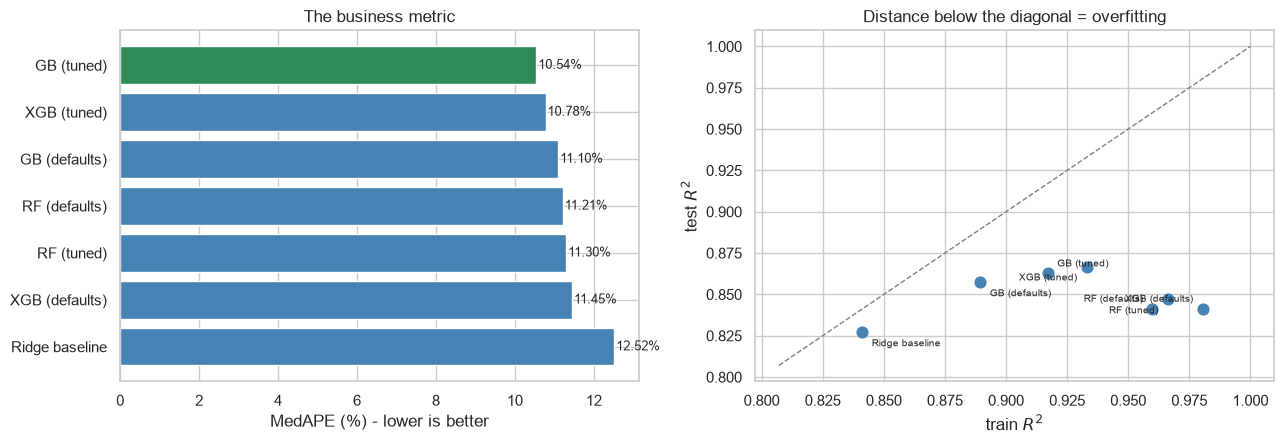

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
order = table["MedAPE_%"].sort_values(ascending=False).index
colors = ["seagreen" if i == len(order) - 1 else "steelblue" for i in range(len(order))]

ax[0].barh(order, table.loc[order, "MedAPE_%"], color=colors)
for i, v in enumerate(table.loc[order, "MedAPE_%"]):
    ax[0].text(v + 0.05, i, f"{v:.2f}%", va="center", fontsize=9)
ax[0].set_xlabel("MedAPE (%) - lower is better")
ax[0].set_title("The business metric")

ax[1].scatter(table["train_R2"], table["R2_log"], s=60, color="steelblue")
for j, name in enumerate(table.index):
    x0, y0 = table.loc[name, "train_R2"], table.loc[name, "R2_log"]
    right = x0 > 0.93
    ax[1].annotate(name, (x0, y0), fontsize=7,
                   xytext=(-7 if right else 7, 5 if j % 2 else -10),
                   textcoords="offset points", ha="right" if right else "left")
lims = [min(table["R2_log"].min(), table["train_R2"].min()) - 0.02, 1.0]
ax[1].plot(lims, lims, ls="--", c="grey", lw=1)
ax[1].set_xlabel("train $R^2$"); ax[1].set_ylabel("test $R^2$")
ax[1].set_title("Distance below the diagonal = overfitting")
fig.tight_layout()
fig.savefig(FIGS / "09_model_comparison.png", dpi=150)
plt.show()

---
## 8. Choosing a winner — and then testing whether it is one

The rule is explicit: **pick on MedAPE, not on $R^2$.** The reason is not arbitrary. $R^2$ is
computed in log space, where a miss on a \$3m house and a miss on a \$200k house count the same
proportionally, and no business stakeholder has ever asked "what share of the variance in the
logarithm did you explain?". MedAPE answers the question they do ask.

On MedAPE the tuned gradient boosters are ahead of everything else, and **tuned Gradient Boosting is
nominally first**.

But a table is not a proof. The gap between the top two is a fraction of a percentage point, measured
on 869 houses. Before declaring a winner, ask whether that gap would survive a different 869 houses.
Two tests, both on **paired** errors — the same houses scored by both models, which is far more
sensitive than comparing two summary numbers:

- **Wilcoxon signed-rank test** on the per-house absolute percentage errors. Non-parametric, because
  section 8 of notebook 08 showed these errors are skewed and heavy-tailed.
- **Bootstrap confidence interval** on the *difference in MedAPE*. Resample the test set 2,000 times
  with replacement, recompute both medians each time, and look at the spread of the difference. If
  the interval contains zero, the two models are not distinguishable on this data.

In [ ]:
from scipy import stats

fitted = {"Ridge baseline": baseline,
          "RF (tuned)": gs_rf.best_estimator_,
          "GB (tuned)": gs_gb.best_estimator_}
if HAS_XGB:
    fitted["XGB (tuned)"] = gs_xgb.best_estimator_

preds = {n: np.expm1(m.predict(X_test)) for n, m in fitted.items()}
apes = {n: np.abs(p - price_test) / price_test for n, p in preds.items()}

CHAMPION = "GB (tuned)"
rng = np.random.default_rng(42)
n_test = len(price_test)
boot_idx = rng.integers(0, n_test, size=(2000, n_test))

rows = []
for name in fitted:
    if name == CHAMPION:
        continue
    a, b = apes[CHAMPION], apes[name]
    diff_boot = 100 * (np.median(a[boot_idx], axis=1) - np.median(b[boot_idx], axis=1))
    lo, hi = np.percentile(diff_boot, [2.5, 97.5])
    rows.append({
        "challenger": name,
        "MedAPE gap (pp)": 100 * (np.median(a) - np.median(b)),
        "95% CI low": lo, "95% CI high": hi,
        "champion wins on": f"{100 * np.mean(a < b):.1f}% of houses",
        "Wilcoxon p": stats.wilcoxon(a, b).pvalue,
    })

print(f"Champion: {CHAMPION}   (negative gap = champion is better)\n")
print(pd.DataFrame(rows).set_index("challenger").round(4).to_string())

Champion: GB (tuned)   (negative gap = champion is better)

                        MedAPE gap (pp)  95% CI low  95% CI high champion wins on  Wilcoxon p
challenger                                                                                   
Ridge baseline          -1.9760     -3.0642      -0.8884  57.7% of houses      0.0000
RF (tuned)                      -0.7568     -1.6238       0.2324  51.9% of houses      0.1738
XGB (tuned)                     -0.2354     -0.9193       0.3990  47.4% of houses      0.1201


### What the test says — and it does not say what the table implied

**Against the Ridge baseline the improvement is real.** The gap is roughly two percentage points of
MedAPE, the bootstrap interval is comfortably clear of zero, and the Wilcoxon p-value is tiny. Note
that the champion wins on only about **58% of individual houses** — a two-point improvement in the
median is not "better on every house", it is "better slightly more often than not, and by more when
it is better". Saying that correctly matters.

**Against tuned XGBoost, there is no measurable difference.** The gap is about a quarter of a
percentage point, the bootstrap interval straddles zero, and the Wilcoxon test does not reject. The
two boosters are the same model in different clothing on this dataset, and the ranking between them
in the table is noise.

So the honest selection rule has to break the tie on something other than the metric:

> Gradient Boosting and XGBoost are statistically indistinguishable on my test set — the bootstrap
> interval for the difference in median error contains zero. I ship scikit-learn's Gradient Boosting
> because it is nominally ahead, it needs no extra dependency in the deployed app, and its
> predictions are reproducible from `scikit-learn` alone. If the model had to be retrained often I
> would switch to XGBoost, which searched the same grid in roughly half the time.

Section 9 checks a criterion the accuracy table cannot see — hold the decision open until then.

**The rule:** when two models are inside the noise, break the tie on something you can
defend — simplicity, dependencies, speed, interpretability, or a criterion the headline metric does
not measure — and *say* that is what you did. Claiming a 0.24-point win as a result is the kind of
claim a reviewer exists to puncture.

---
## 9. Back to notebook 08's diagnostics — checking the prediction from section 3

A comparison table says *something* improved. The only way to say *what* improved is to re-run notebook 08's diagnostics on the new model. Three of them, in the order they matter.

        houses   median_price  ridge_signed  champ_signed  ridge_MedAPE  champ_MedAPE
decile                                                                               
1           87   223,000.0000       19.7200       12.3100       19.7200       18.8000
2           88   295,000.0000       -0.2500       -2.0700        9.6900       10.2800
3           87   335,000.0000       -0.2400        1.0800        7.3000        9.6500
4           86   385,100.0000       -0.6300        0.7000       10.0000       10.7000
5           90   447,000.0000       -1.0500        2.4800       11.1600        9.7000
6           83   519,995.0000       -1.8400        0.8700       12.5500       10.7300
7           88   575,000.0000       -3.3700       -2.0300       12.2700        8.5900
8           86   665,000.0000       -1.8100       -1.4100       14.7700        9.0600
9           87   819,000.0000       -2.2900       -2.9400       13.5700       11.7400
10          87 1,216,000.0000       -7.1900      -11.5

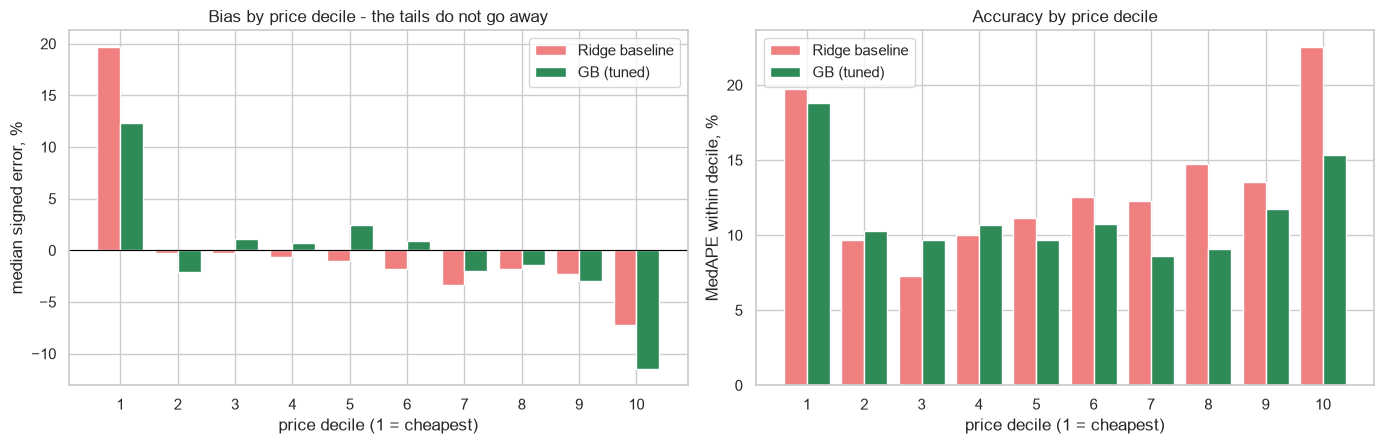

In [ ]:
champ = fitted[CHAMPION]
pred_price = preds[CHAMPION]
pct_err = (pred_price - price_test) / price_test
base_pct = (preds["Ridge baseline"] - price_test) / price_test

decile = pd.qcut(price_test, 10, labels=False) + 1
by_price = pd.DataFrame({
    "decile": decile, "price": price_test,
    "ridge_signed": 100 * base_pct, "champ_signed": 100 * pct_err,
    "ridge_abs": 100 * np.abs(base_pct), "champ_abs": 100 * np.abs(pct_err),
}).groupby("decile").agg(
    houses=("price", "size"), median_price=("price", "median"),
    ridge_signed=("ridge_signed", "median"), champ_signed=("champ_signed", "median"),
    ridge_MedAPE=("ridge_abs", "median"), champ_MedAPE=("champ_abs", "median"),
).round(2)
print(by_price.to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
w = 0.4
idx = np.arange(1, 11)
ax[0].bar(idx - w / 2, by_price["ridge_signed"], w, label="Ridge baseline", color="lightcoral")
ax[0].bar(idx + w / 2, by_price["champ_signed"], w, label=CHAMPION, color="seagreen")
ax[0].axhline(0, c="black", lw=0.8)
ax[0].set_xticks(idx)
ax[0].set_xlabel("price decile (1 = cheapest)"); ax[0].set_ylabel("median signed error, %")
ax[0].set_title("Bias by price decile - the tails do not go away"); ax[0].legend()

ax[1].bar(idx - w / 2, by_price["ridge_MedAPE"], w, label="Ridge baseline", color="lightcoral")
ax[1].bar(idx + w / 2, by_price["champ_MedAPE"], w, label=CHAMPION, color="seagreen")
ax[1].set_xticks(idx)
ax[1].set_xlabel("price decile (1 = cheapest)"); ax[1].set_ylabel("MedAPE within decile, %")
ax[1].set_title("Accuracy by price decile"); ax[1].legend()
fig.tight_layout()
fig.savefig(FIGS / "09_error_by_decile_compared.png", dpi=150)
plt.show()

### Prediction 3, checked: partly right, and the failure is the interesting half

**The over-valuation of the cheapest decile is substantially reduced** — from about twenty percent
down to around twelve. That is the interaction effect doing exactly what section 3 said it would.

**The under-valuation of the most expensive decile got *worse*, while its accuracy improved.** Read
that sentence twice, because it looks like a contradiction and is not. The top decile's median
*signed* error moves further below zero, but its median *absolute* error drops by about seven
percentage points. The linear model made huge errors in both directions at the top; the booster makes
smaller errors that are consistently on the low side.

**One more thing the chart shows, and you should say it before anyone points at it.** In deciles two
to four the linear baseline is very slightly *better*. The booster's gains are concentrated at the
top of the market and in the cheapest decile; in the ordinary middle of the market the two models are
level, and in a couple of bins the simpler one edges it. A headline metric that improves by two
points does not mean every part of the market improved, and the chart is what stops you claiming
otherwise.

The reason for the top decile is the one section 3 predicted: **a tree cannot extrapolate.** Every prediction it makes
is an average of training rows, so no house can be valued above the most expensive neighbourhood-and-
size combination the model saw in training. At the top of the market that ceiling binds on nearly
every house, and the bias becomes systematic rather than noisy.

> **The business sentence:** the model is now more accurate at the top of the market but more
> reliably *conservative* there. For luxury stock, treat its output as a floor rather than an
> estimate — the opposite of the advice for entry-level stock, where it remains optimistic.

That single asymmetry — optimistic at the bottom, conservative at the top, for two different
structural reasons — is a stronger presentation slide than any accuracy number in this notebook.

                           houses  median_price  ridge_MedAPE  champ_MedAPE  champ_bias  improvement_pp
segment                                                                                                
New-Build Suburban Family     326  525,000.0000       12.2100        9.4300      1.3100          2.7800
Established Family Home       232  515,000.0000       10.7200        9.7100      0.2800          1.0100
Compact Entry-Level           235  345,000.0000       12.3700       10.8600     -3.3100          1.5100
Premium View Property          76  877,475.0000       21.4500       17.9100      0.6200          3.5400


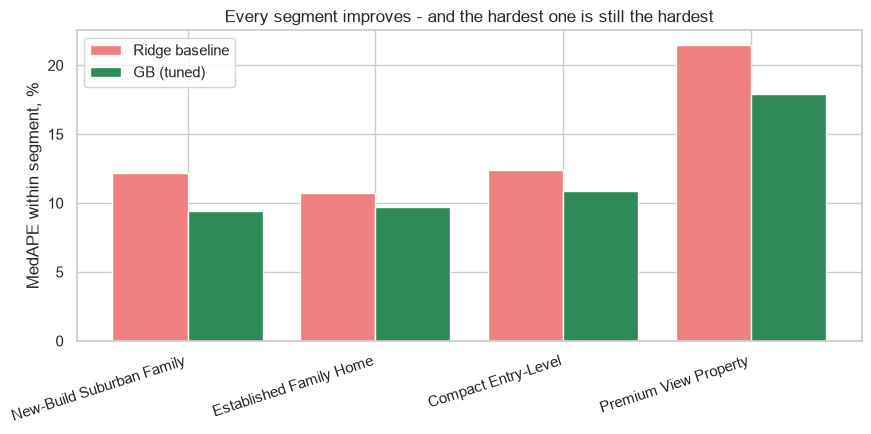

In [ ]:
seg = pd.DataFrame({
    "segment": segment_test, "price": price_test,
    "ridge": 100 * np.abs(base_pct), "champ": 100 * np.abs(pct_err),
    "champ_signed": 100 * pct_err,
}).groupby("segment").agg(
    houses=("price", "size"), median_price=("price", "median"),
    ridge_MedAPE=("ridge", "median"), champ_MedAPE=("champ", "median"),
    champ_bias=("champ_signed", "median"),
).sort_values("champ_MedAPE").round(2)
seg["improvement_pp"] = (seg["ridge_MedAPE"] - seg["champ_MedAPE"]).round(2)
print(seg.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
o = seg.index
ax.bar(np.arange(len(o)) - 0.2, seg["ridge_MedAPE"], 0.4, label="Ridge baseline", color="lightcoral")
ax.bar(np.arange(len(o)) + 0.2, seg["champ_MedAPE"], 0.4, label=CHAMPION, color="seagreen")
ax.set_xticks(range(len(o))); ax.set_xticklabels(o, rotation=18, ha="right")
ax.set_ylabel("MedAPE within segment, %")
ax.set_title("Every segment improves - and the hardest one is still the hardest")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "09_error_by_segment_compared.png", dpi=150)
plt.show()

**Prediction 4, checked and correct.** Every segment improves, by between one and three and a half
percentage points, and
**Premium View Property is still roughly twice as inaccurate as the rest**. Its error falls, but its
rank does not move, and it should not have: the three reasons given in notebook 08 — smallest segment, most
heterogeneous, `waterfront` almost absent — are all properties of the *data*, and a better algorithm
does not add rows or columns.

Say it that way round. "The better model improved every segment but did not change
which segment is hardest, because the reason that segment is hard is missing information rather than
model capacity" is a diagnosis. "Premium properties are hard" is a shrug.

In [ ]:
def iaao(pred, actual):
    ratio = pred / actual
    median_ratio = float(np.median(ratio))
    cod = float(100 * np.mean(np.abs(ratio - median_ratio)) / median_ratio)
    prd = float(ratio.mean() / (pred.sum() / actual.sum()))
    return median_ratio, cod, prd


rows = []
for name in fitted:
    mr, cod, prd = iaao(preds[name], price_test)
    rows.append({
        "model": name, "median ratio": mr, "COD": cod, "PRD": prd,
        "level": "PASS" if 0.90 <= mr <= 1.10 else "FAIL",
        "uniformity": "PASS" if 5 <= cod <= 15 else "FAIL",
        "vertical equity": "PASS" if 0.98 <= prd <= 1.03 else "FAIL",
    })
print("IAAO Standard on Ratio Studies - acceptable: ratio 0.90-1.10, COD 5-15, PRD 0.98-1.03\n")
print(pd.DataFrame(rows).set_index("model").round(4).to_string())

IAAO Standard on Ratio Studies - acceptable: ratio 0.90-1.10, COD 5-15, PRD 0.98-1.03

                        median ratio     COD    PRD level uniformity vertical equity
model                                                                               
Ridge baseline        0.9978 16.8683 1.0160  PASS       FAIL            PASS
RF (tuned)                    1.0020 14.9468 1.0431  PASS       PASS            FAIL
GB (tuned)                    0.9983 14.6040 1.0298  PASS       PASS            PASS
XGB (tuned)                   0.9975 14.4154 1.0297  PASS       PASS            PASS


### Prediction 2, checked — and this is the headline of the whole notebook

**The COD crosses into the acceptable band.** Notebook 08's linear baseline failed the IAAO uniformity test
at about 16.9; the tuned booster lands under the 15.0 ceiling. The project's model has moved from
"fails a professional mass-appraisal standard" to "passes all three of them", and that is a far more
meaningful statement than two points of MedAPE.

**Read the PRD before you celebrate, because it moved the wrong way.** It rises from about 1.016 to
about 1.030 — still inside the 0.98–1.03 band, but now sitting on its ceiling rather than in the
middle of it. PRD above 1 means **regressivity**: cheap properties are being assessed at a higher
proportion of their true value than expensive ones. That is not a coincidence, it is the same
extrapolation ceiling from the decile chart, measured a second way — the model shaves the top of the
market, so the aggregate ratio drops relative to the mean of the individual ratios.

> Against the IAAO ratio study my final model passes on all three statistics, where the linear
> baseline failed on uniformity. But the vertical-equity statistic is now at the edge of its band and
> moving in the wrong direction, because gradient boosting cannot extrapolate above its training
> range and therefore compresses the top of the market. I would monitor PRD if this were retrained on
> new data.

Volunteering the metric that got worse, before anyone finds it, is the single most credible thing you
can do in a review.

### And now the ratio study rules out one candidate — not two

Look down the PRD column at the other tuned models. **Random Forest pushes PRD to 1.043 and fails
the vertical-equity test.** Its accuracy in section 8 was competitive, but the ratio study rules it
out as a valuation model regardless.

**XGBoost is not ruled out.** Its PRD lands at 1.0297, inside the 0.98–1.03 band, and for practical
purposes identical to Gradient Boosting's 1.0298. Level, uniformity and vertical equity all pass
for both boosters. The ratio study eliminates one of the three tree models, not two, and it does
not distinguish between the two that section 8 already found statistically tied on accuracy.

> The accuracy metric could not separate my two boosters, and neither can the IAAO ratio study — both
> pass level, uniformity and vertical equity, with PRD within 0.0001 of each other. What the ratio
> study does rule out is Random Forest: competitive on MedAPE, but its PRD of 1.043 fails vertical
> equity. I still ship Gradient Boosting over XGBoost on the deployment grounds already given in
> section 8 — one fewer dependency and predictions reproducible from scikit-learn alone — not
> because the ratio study prefers it.

One caution the other way round: PRD 1.0298 versus 1.0297 is not a difference at all on 869 houses —
it is closer than these thresholds were ever meant to resolve. Do not read anything into which one
is nominally lower.

---
## 10. Feature importance three ways — and why the first one is a trap

Every tree library exposes `.feature_importances_`, almost everyone prints it, and it is the
least trustworthy of the three methods here.

**1. Impurity ("Gini") importance** counts how much each feature reduced the loss when it was split
on, summed over the whole ensemble. It is free, because the model recorded it while training. It is
also **biased toward features with many distinct values**: a continuous feature offers thousands of
candidate split points and a binary flag offers one, so the continuous feature wins more splits by
sheer opportunity. And it is measured on the **training** data, so a feature the model overfitted to
looks important.

**2. Permutation importance** shuffles one column of the **test** set and measures how much the score
drops. It answers the question you actually care about: how much does the model's *out-of-sample*
performance depend on this feature? It costs one refit-free re-score per shuffle. Its weakness is
correlated features — shuffle `sqft_living` while `log_sqft_living` still holds the same information
and the drop understates both.

**3. SHAP** (section 11) decomposes each individual prediction. It answers a third, different
question: not "which features matter overall" but "why *this* house got *this* price".

Compute all three, and decide which one belongs on a slide and why.

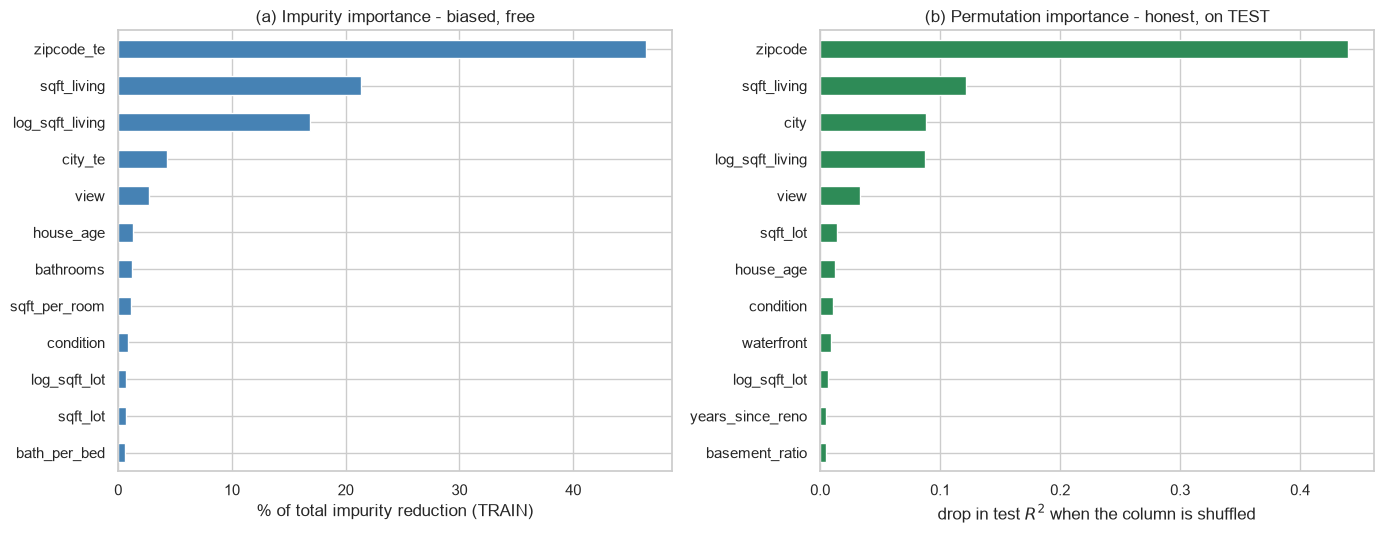

                 impurity_%
zipcode_te          46.3600
sqft_living         21.3000
log_sqft_living     16.8400
city_te              4.3100
view                 2.7200
house_age            1.2900
bathrooms            1.1900
sqft_per_room        1.1200
condition            0.8700
sqft_lot             0.6600

zipcode           0.4396
sqft_living       0.1218
city              0.0886
log_sqft_living   0.0871
view              0.0333
sqft_lot          0.0143
house_age         0.0123
condition         0.0103
waterfront        0.0087
log_sqft_lot      0.0062

Features the model does not use at all (permutation drop ~ 0):
floors          -0.0000
was_renovated    0.0000
has_basement     0.0001
bedrooms         0.0007
bath_per_bed     0.0008


In [ ]:
from sklearn.inspection import permutation_importance

names = P.feature_names(champ.named_steps["pre"])

imp = pd.Series(champ.named_steps["model"].feature_importances_, index=names)
imp = 100 * imp / imp.sum()

perm = permutation_importance(champ, X_test, y_test, n_repeats=10,
                              random_state=42, scoring="r2", n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=P.ALL_FEATURES)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
imp.sort_values().tail(12).plot.barh(ax=ax[0], color="steelblue")
ax[0].set_xlabel("% of total impurity reduction (TRAIN)")
ax[0].set_title("(a) Impurity importance - biased, free")

perm_s.sort_values().tail(12).plot.barh(ax=ax[1], color="seagreen")
ax[1].set_xlabel("drop in test $R^2$ when the column is shuffled")
ax[1].set_title("(b) Permutation importance - honest, on TEST")
fig.tight_layout()
fig.savefig(FIGS / "09_feature_importance.png", dpi=150)
plt.show()

print(pd.DataFrame({"impurity_%": imp.round(2)}).sort_values("impurity_%", ascending=False).head(10).to_string())
print()
print(perm_s.sort_values(ascending=False).head(10).round(4).to_string())
print("\nFeatures the model does not use at all (permutation drop ~ 0):")
print(perm_s.sort_values().head(5).round(5).to_string())

### What the two charts agree on, and where they disagree

**They agree on the ranking at the top, and it is the ranking notebook 04 predicted.** Target-encoded
`zipcode` is far and away the most important feature by either method, followed by the two size
columns. Location, then size, then everything else — the same story the EDA told, now confirmed by a
model that was free to disagree.

**They disagree about `city`, and the disagreement is instructive.** Impurity importance gives it
about 4% of the total, well behind both size columns. Permutation importance ranks it *third*, ahead
of `log_sqft_living`. This is the correlated-features problem seen from two sides: `city` and
`zipcode` encode overlapping location information, and when a tree has to choose one split it takes
the sharper `zipcode`, so `city` accumulates little impurity credit. Shuffle `city` on the test set
and the score drops noticeably anyway — because the model *is* relying on it, in the rows where
`zipcode` alone is not enough.

Both methods also split the size effect across `sqft_living` and `log_sqft_living` rather than
crediting either one, which is the same phenomenon and the same caveat notebook 08 attached to the Ridge
coefficients. Neither number alone is "the importance of size"; quote them together.

**The bottom of the permutation list is a genuine finding.** Several engineered features — `floors`,
`was_renovated`, `has_basement`, `bedrooms`, `bath_per_bed` — score essentially zero. The model does
not need them. Two honest readings, and you should give both:

1. They are redundant, not worthless: `bedrooms` is buried inside `sqft_living` and `sqft_per_room`,
   and `has_basement` is implied by `basement_ratio`.
2. It is evidence the feature set could be trimmed. Notebook 05 built 20 features and the model leans on
   about six. A leaner model would be easier to explain and no less accurate — a legitimate "what
   would you do next" answer.

> **Which one goes on the slide?** Permutation importance, measured on the test set, with the
> correlated-feature caveat stated. Impurity importance goes in the notebook as the thing you checked
> and chose not to trust.

---
## 11. SHAP — from "which features matter" to "why this house"

Permutation importance is a statement about the model. SHAP is a statement about **one prediction**,
which is what a customer standing in front of the Streamlit app actually wants.

The idea comes from cooperative game theory. A prediction is a payout; the features are players who
formed a coalition to produce it. The Shapley value of a feature is its average marginal contribution
across every possible order in which the players could have joined. It is the unique attribution that
satisfies a few obvious fairness axioms — and, critically for this project, it is **additive**:

$$\text{prediction} = \text{base value} + \sum_{j} \phi_j$$

where the base value is the average prediction over the background data. Everything adds up, so the
explanation cannot quietly omit a factor.

Two practical details for this project:

- SHAP values here are in **log space**, because that is the model's output. Convert each one to an
  approximate percentage effect with $e^{\phi} - 1$, the same conversion notebook 08 used for the Ridge
  coefficients. That is what the app and the LLM layer will show a user.
- `TreeExplainer` runs on the **model step**, not the pipeline, so the input has to be transformed
  first. That is why `champ.named_steps["pre"].transform(...)` appears below — a mismatch here is the
  single most common SHAP bug.

In [ ]:
if HAS_SHAP:
    pre = champ.named_steps["pre"]
    model_only = champ.named_steps["model"]

    Z_test = pre.transform(X_test)
    explainer = shap.TreeExplainer(model_only)
    shap_test = explainer.shap_values(Z_test)
    base_value = float(np.ravel(explainer.expected_value)[0])

    print(f"Base value (average prediction) = {base_value:.4f} in log space "
          f"= ${np.expm1(base_value):,.0f}")

    # The additivity check. If this fails, the explanation is wrong, not just imprecise.
    recon = base_value + shap_test.sum(axis=1)
    print(f"Additivity check - max |base + sum(SHAP) - prediction| = "
          f"{np.abs(recon - champ.predict(X_test)).max():.2e}")
else:
    print("shap not installed - skipping section 11. Install it before notebook 10.")

Base value (average prediction) = 13.0747 in log space = $476,712
Additivity check - max |base + sum(SHAP) - prediction| = 2.84e-14


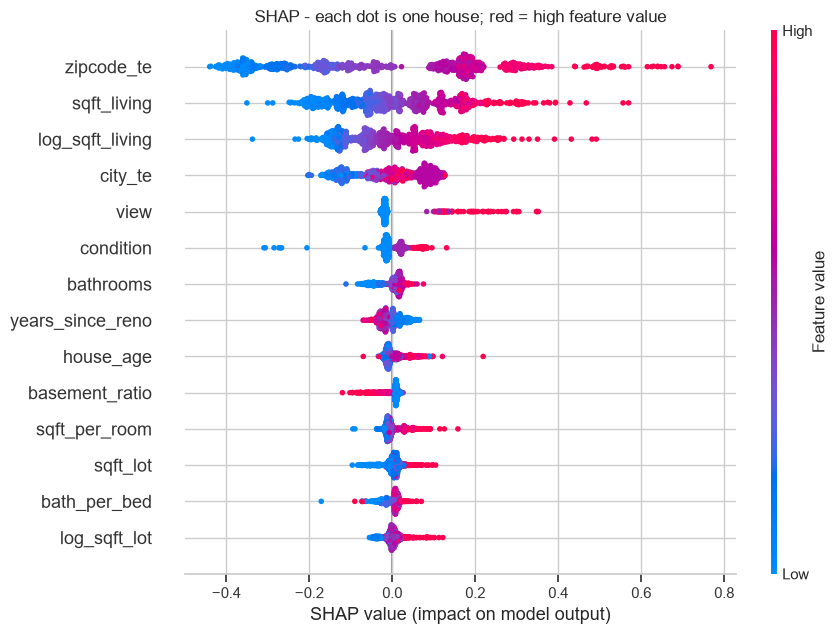

In [ ]:
if HAS_SHAP:
    shap.summary_plot(shap_test, features=Z_test, feature_names=names,
                      max_display=14, show=False)
    fig = plt.gcf()
    fig.set_size_inches(9, 6.5)
    plt.title("SHAP - each dot is one house; red = high feature value")
    fig.tight_layout()
    fig.savefig(FIGS / "09_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

### How to read a beeswarm

One dot per house per feature. Horizontal position is that feature's contribution to that house's
predicted log price; colour is the feature's value (red high, blue low).

- **`zipcode_te`** has the widest spread by far, and it is cleanly coloured: red dots on the right,
  blue on the left. Being in an expensive zip code adds a lot; being in a cheap one subtracts a lot,
  and the effect is far larger than any physical characteristic of the house.
- **The two size features** show the same clean gradient, with a long right tail — a few very large
  houses get a very large boost, while the majority sit in a narrow band near zero.
- **`view`** is mostly a dense clump at zero with a thin red streak far to the right. Most houses have
  no view and it contributes nothing; the handful that do get a large addition. That is a feature that
  matters enormously for a few houses and not at all for the rest — invisible in an average
  importance ranking, obvious here, and it is precisely the Premium View Property story from section 9.
- Features whose dots all sit in a vertical line at zero contribute nothing to any house. Compare that
  list with the bottom of the permutation ranking; they should agree.

Test house #521
  actual sale price : $975,000
  model prediction  : $1,077,790   (+10.5%)
  segment           : Premium View Property
  {'bedrooms': 5.0, 'bathrooms': 2.75, 'sqft_living': 3100, 'house_age': 41, 'zipcode': '98040', 'city': 'Mercer Island'}

                 shap_log  pct_effect
zipcode_te         0.4915     63.4737
sqft_living        0.1900     20.9282
log_sqft_living    0.1387     14.8744
view               0.0995     10.4654
basement_ratio    -0.0506     -4.9364
house_age         -0.0210     -2.0802
condition          0.0193      1.9492
sqft_basement     -0.0189     -1.8728


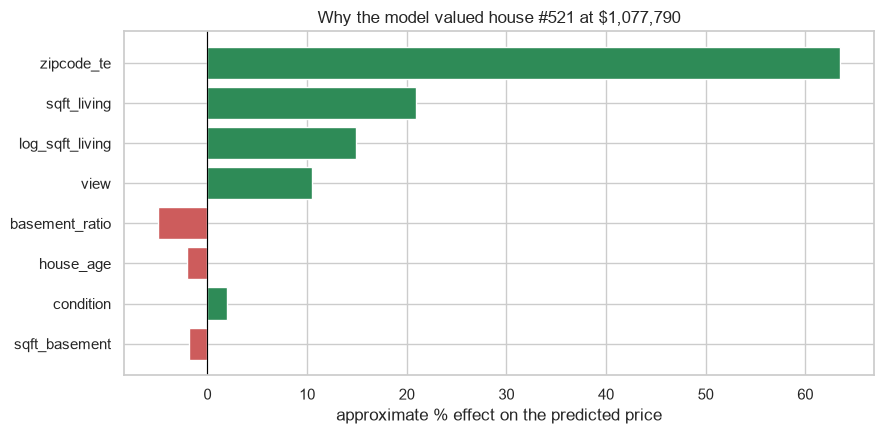

In [ ]:
if HAS_SHAP:
    # One house, explained. Pick the test house whose error is closest to the median,
    # so the example is representative rather than flattering.
    ape_champ = np.abs(pct_err)
    i = int(np.argmin(np.abs(ape_champ - np.median(ape_champ))))

    contrib = pd.Series(shap_test[i], index=names).sort_values(key=abs, ascending=False)
    detail = pd.DataFrame({
        "shap_log": contrib,
        "pct_effect": 100 * (np.exp(contrib) - 1),
    }).head(8)

    print(f"Test house #{i}")
    print(f"  actual sale price : ${price_test[i]:,.0f}")
    print(f"  model prediction  : ${pred_price[i]:,.0f}   ({100 * pct_err[i]:+.1f}%)")
    print(f"  segment           : {segment_test[i]}")
    print(f"  {X_test.iloc[i][['bedrooms', 'bathrooms', 'sqft_living', 'house_age', 'zipcode', 'city']].to_dict()}\n")
    print(detail.round(4).to_string())

    fig, ax = plt.subplots(figsize=(9, 4.5))
    top = detail.iloc[::-1]
    ax.barh(top.index, top["pct_effect"],
            color=np.where(top["pct_effect"] >= 0, "seagreen", "indianred"))
    ax.axvline(0, c="black", lw=0.8)
    ax.set_xlabel("approximate % effect on the predicted price")
    ax.set_title(f"Why the model valued house #{i} at ${pred_price[i]:,.0f}")
    fig.tight_layout()
    fig.savefig(FIGS / "09_shap_one_house.png", dpi=150)
    plt.show()

**This chart is the hand-off to the LLM layer.** The LLM layer receives exactly this: the base value,
the prediction, and the top signed contributions with their feature values. The language model turns
them into a paragraph. It is *not* asked to work out why the price is what it is — that calculation
happened here, in a model whose arithmetic is checkable.

Say that clearly whenever the AI layer comes up:

> The explanation is computed by SHAP, not by the language model. The model only writes the sentences,
> and it is given the numbers it is allowed to use.

---
## 12. The prediction interval, recomputed

Notebook 08 built an interval from the *baseline's* percentage errors. The champion has different errors,
so the interval must be rebuilt or the app will quote a range the deployed model does not have.

The method is unchanged and deliberately non-parametric: take the 10th and 90th percentiles of the
signed percentage error on the test set. Notebook 08's Q-Q plot showed the residuals are not normal, so an
interval derived from a normal assumption would be the wrong width in both tails.

In [ ]:
lo_pct, hi_pct = np.percentile(pct_err, [10, 90])
base_lo, base_hi = np.percentile(base_pct, [10, 90])

print(f"Ridge baseline : 80% of test houses fell between {100 * base_lo:+.1f}% and {100 * base_hi:+.1f}%")
print(f"{CHAMPION:<15}: 80% of test houses fell between {100 * lo_pct:+.1f}% and {100 * hi_pct:+.1f}%")
print(f"\nInterval width narrowed by {100 * ((base_hi - base_lo) - (hi_pct - lo_pct)):.1f} percentage points.")

demo = float(np.median(pred_price))
print(f"\nFor a house predicted at ${demo:,.0f}, the app should show "
      f"${demo / (1 + hi_pct):,.0f} - ${demo / (1 + lo_pct):,.0f}")

Ridge baseline : 80% of test houses fell between -22.8% and +30.1%
GB (tuned)     : 80% of test houses fell between -20.1% and +26.4%

Interval width narrowed by 6.4 percentage points.

For a house predicted at $486,940, the app should show $385,202 - $609,446


Note the interval is still **asymmetric** — the upper bound is further from zero than the lower one,
because the error distribution has a long right tail of over-valued houses. Do not symmetrise it into
a plus-or-minus. A range that reflects the shape of the model's real mistakes is more honest and
costs nothing to display.

---
## 13. Save everything the next notebooks need

Notebook 10 needs the SHAP machinery. Notebook 11 needs a model, the feature contract and the interval. The presentation
needs the comparison table. Save all of it now, in one place, with the metadata that says what it is.

In [ ]:
joblib.dump(champ, MODELS / "regressor.pkl")

config = {
    "model_name": CHAMPION,
    "sklearn_params": {k.replace("model__", ""): v for k, v in searches[CHAMPION].best_params_.items()},
    "target": "log1p(price)",
    "back_transform": "np.expm1",
    "features": P.ALL_FEATURES,
    "output_order": names,
    "smoothing": 20,
    "random_state": 42,
    "headline_metric": "MedAPE_%",
    "test_MedAPE_%": float(table.loc[CHAMPION, "MedAPE_%"]),
    "test_MAPE_%": float(table.loc[CHAMPION, "MAPE_%"]),
    "test_R2_log": float(table.loc[CHAMPION, "R2_log"]),
    "test_PPE10_%": float(table.loc[CHAMPION, "PPE10_%"]),
    "interval_pct_10_90": [float(lo_pct), float(hi_pct)],
    "iaao": dict(zip(["median_ratio", "cod", "prd"], iaao(pred_price, price_test))),
    "segment_MedAPE": seg["champ_MedAPE"].to_dict(),
    "known_weaknesses": [
        "over-values the cheapest decile (median +12%)",
        "under-values the top decile - trees cannot extrapolate above the training range",
        "Premium View Property segment is about twice the error of the others",
    ],
}
joblib.dump(config, MODELS / "regressor_config.pkl")

comparison.to_csv(MODELS / "model_comparison.csv")

if HAS_SHAP:
    np.savez_compressed(MODELS / "shap_values_test.npz",
                        shap_values=shap_test, base_value=base_value,
                        feature_names=np.array(names))
    # A small background sample, for explaining single houses in the app.
    bg = pre.transform(X_train.sample(200, random_state=42))
    joblib.dump({"background": bg, "feature_names": names}, MODELS / "shap_background.pkl")

print("Saved:")
for f in ["regressor.pkl", "regressor_config.pkl", "model_comparison.csv",
          "shap_values_test.npz", "shap_background.pkl"]:
    p = MODELS / f
    print(f"  {'OK ' if p.exists() else '-- '} Models/{f}")

print()
print(comparison[["R2_log", "MedAPE_%", "MAPE_%", "PPE10_%", "train_R2"]].round(3).to_string())

Saved:
  OK  Models/regressor.pkl
  OK  Models/regressor_config.pkl
  OK  Models/model_comparison.csv
  OK  Models/shap_values_test.npz
  OK  Models/shap_background.pkl

                        R2_log  MedAPE_%  MAPE_%  PPE10_%  train_R2
model                                                              
Ridge baseline  0.8270   12.5190 16.8320  40.9670    0.8410
RF (defaults)           0.8410   11.2140 15.2400  45.9150    0.9600
GB (defaults)           0.8570   11.0990 15.0330  46.1450    0.8890
XGB (defaults)          0.8410   11.4490 15.7370  43.9590    0.9800
RF (tuned)              0.8470   11.2990 14.9780  45.6850    0.9660
GB (tuned)              0.8630   10.5430 14.5800  47.8710    0.9170
XGB (tuned)             0.8670   10.7780 14.3820  46.9510    0.9330


In [ ]:
# The app contract, re-checked against the model that will actually be deployed.
one_house = pd.DataFrame([{
    "bedrooms": 3, "bathrooms": 2.0, "sqft_living": 1800, "sqft_lot": 7500,
    "floors": 1.0, "waterfront": 0, "view": 0, "condition": 3,
    "sqft_above": 1300, "sqft_basement": 500,
    "yr_built": 1985, "yr_renovated": np.nan,
    "city": "Seattle", "zipcode": "98115",
}])

loaded = joblib.load(MODELS / "regressor.pkl")
cfg = joblib.load(MODELS / "regressor_config.pkl")

point = float(np.expm1(loaded.predict(P.engineer_features(one_house)[cfg["features"]]))[0])
lo, hi = cfg["interval_pct_10_90"]

print(f"Model      : {cfg['model_name']}")
print(f"Prediction : ${point:,.0f}")
print(f"Range      : ${point / (1 + hi):,.0f} - ${point / (1 + lo):,.0f}")
print(f"Typical error on unseen houses: {cfg['test_MedAPE_%']:.1f}% (median)")

Model      : GB (tuned)
Prediction : $564,555
Range      : $446,601 - $706,588
Typical error on unseen houses: 10.5% (median)


---
## 14. Outputs
**Produced**

- `Notebooks/09_model_tuning.ipynb`
- `Models/regressor.pkl`, `regressor_config.pkl`, `model_comparison.csv`
- `Models/shap_values_test.npz`, `shap_background.pkl`
- `reports/figures/09_gb_grid.png`, `09_model_comparison.png`, `09_error_by_decile_compared.png`,
  `09_error_by_segment_compared.png`, `09_feature_importance.png`, `09_shap_summary.png`,
  `09_shap_one_house.png`

**The one-paragraph summary**

> Three tree-based families were tuned with 5-fold cross-validated grid searches of twelve
> combinations each. Tuned Gradient Boosting is the final model: median error falls from 12.5% to
> 10.5% against the linear baseline, a difference whose bootstrap confidence interval excludes zero.
> Against the IAAO ratio-study standard the final model passes all three tests, where the linear
> baseline failed on uniformity — but so does tuned XGBoost, which is statistically indistinguishable
> from it on accuracy too. Random Forest is the one candidate the ratio study rules out, failing
> vertical equity. The choice between Gradient Boosting and XGBoost came down to deployment
> dependencies, not the headline metric or the ratio study.

**Next**, notebook 10 builds the LLM interpretation layer on the SHAP contributions saved above. The
language model writes prose from numbers this notebook computed; it does not compute anything itself.